In [ ]:
!pip install trimesh -q

In [ ]:
import json
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/pointcloud/params'

# Create the directory if it doesn't already exist
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, 'parameters.json')

# 1. Define your program parameters in a dictionary
parameters = {
    "pixel_pitch": 3.74e-6,
    "wavelength": 632.8e-9,
    "axis_dist": 0.9999,
    "img_width": 3840,
    "img_height": 2180,
    "target_vram_gb": 10.0,
    "generate_hologram": True,
    "optimize_gs": True,
    "img_path": "/content/drive/MyDrive/pointcloud/CGHs/zmienNazwe.png",
}

# 2. Save the parameters to a JSON file
with open(file_path, "w") as json_file:
    # indent=4 formats the file to be easily readable by humans
    json.dump(parameters, json_file, indent=4)

print("Parameters successfully saved to: ",file_path)

Mounted at /content/drive
Parameters successfully saved to:  /content/drive/MyDrive/pointcloud/params/parameters.json


In [ ]:
params_path = '/content/drive/MyDrive/pointcloud/params/parameters.json'

with open(params_path, "r") as json_file:
    loaded_params = json.load(json_file)

# Load the global program parameters

pixel_pitch = loaded_params["pixel_pitch"]
wavelength = loaded_params["wavelength"]
axis_dist = loaded_params["axis_dist"]
width = loaded_params["img_width"]
height = loaded_params["img_height"]
target_vram_gb = loaded_params["target_vram_gb"]
generate_hologram = loaded_params["generate_hologram"]
optimize_gs = loaded_params["optimize_gs"]
img_path = loaded_params["img_path"]

# instrukcja warunkowa optymalizacji GS
if generate_hologram != True:
    optimize_gs = False
    print("Tryb odczytu jest włączony. Ustaw generate_holograms na TRUE")

In [ ]:
!pip install moderngl trimesh pyrr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 5.2 MB/s eta 0:00:00


In [ ]:
import trimesh
import torch
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


filename = "/content/drive/MyDrive/pointcloud/Eta2/Eta2_whole.obj"


# force='scene' gwarantuje, że trimesh nie scali geometrii w jedną bryłę
scene = trimesh.load(filename, force='scene')

# scene.geometry to słownik {nazwa_części: Trimesh}
parts = []
for name, mesh in scene.geometry.items():
    # Pobieramy dedykowane dane dla danej pod-siatki
    vbo_data = mesh.vertices.astype('f4')
    normals_data = mesh.vertex_normals.astype('f4')
    uv_data = mesh.visual.uv.astype('f4')
    faces_data = mesh.faces.astype('i4')

    # Sprawdzenie powiązanego materiału/tekstury
    tex_image = None
    if hasattr(mesh.visual, 'material') and hasattr(mesh.visual.material, 'image'):
        tex_image = mesh.visual.material.image  # Obraz PIL Image przypisany do tej części

    parts.append({
        'name': name,
        'vertices': vbo_data,
        'normals': normals_data,
        'uvs': uv_data,
        'faces': faces_data,
        'texture': tex_image
    })


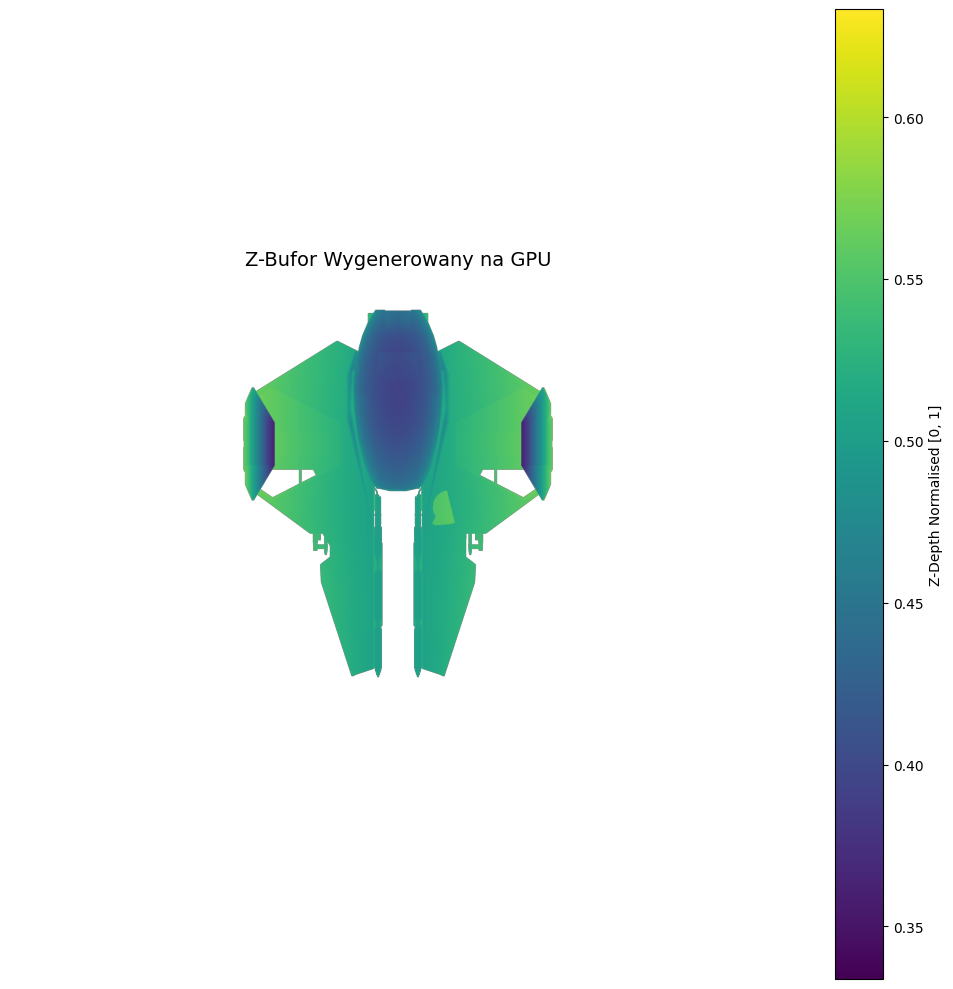

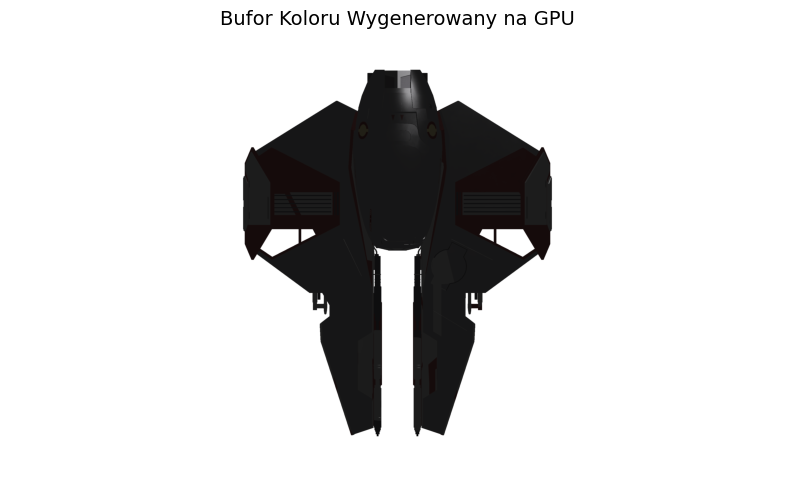

In [ ]:
import trimesh
import torch
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


filename = "/content/drive/MyDrive/pointcloud/Eta2/Eta2_whole.obj"


# force='scene' gwarantuje, że trimesh nie scali geometrii w jedną bryłę
scene = trimesh.load(filename, force='scene')

# scene.geometry to słownik {nazwa_części: Trimesh}
parts = []
for name, mesh in scene.geometry.items():
    # Pobieramy dedykowane dane dla danej pod-siatki
    vbo_data = mesh.vertices.astype('f4')
    normals_data = mesh.vertex_normals.astype('f4')
    uv_data = mesh.visual.uv.astype('f4')
    faces_data = mesh.faces.astype('i4')

    # Sprawdzenie powiązanego materiału/tekstury
    tex_image = None
    if hasattr(mesh.visual, 'material') and hasattr(mesh.visual.material, 'image'):
        tex_image = mesh.visual.material.image  # Obraz PIL Image przypisany do tej części

    parts.append({
        'name': name,
        'vertices': vbo_data,
        'normals': normals_data,
        'uvs': uv_data,
        'faces': faces_data,
        'texture': tex_image
    })


from pyrr import Matrix44, Vector3 # Lekka biblioteka do macierzy transformacji
import moderngl
from PIL import Image

# =====================================================================
# KROK 2: INICJALIZACJA KONTEKSTU GPU (Headless)
# =====================================================================
# Tworzymy niezależny kontekst OpenGL bez otwierania okna systemu operacyjnego
ctx = moderngl.create_context(standalone=True, backend='egl')
ctx.enable(moderngl.DEPTH_TEST) # Włączenie sprzętowego Z-bufora

# =====================================================================
# KROK 3: SHADERY
# =====================================================================

# Vertex Shader
vertex_shader = '''
#version 330 core

in vec3 in_position;
in vec3 in_normal;
in vec2 in_uv;

out vec3 v_world_pos;
out vec3 v_normal;
out vec2 v_uv;

uniform mat4 u_proj;
uniform mat4 u_view;
uniform mat4 u_model;

void main() {
    vec4 world_pos = u_model * vec4(in_position, 1.0);
    v_world_pos = world_pos.xyz;

    // Transformacja wektora normalnego do przestrzeni świata
    v_normal = mat3(transpose(inverse(u_model))) * in_normal;
    v_uv = in_uv;

    gl_Position = u_proj * u_view * world_pos;
}
'''

# Fragment Shader
fragment_shader = '''
#version 330 core

in vec3 v_world_pos;
in vec3 v_normal;
in vec2 v_uv;

out vec4 fragColor;

// 0: Kolor bazowy (podmieniany w pętli)
uniform sampler2D u_albedo;
// 1, 2, 3: Właściwości powierzchni (stałe dla metalu)
uniform sampler2D u_normal_map;
uniform sampler2D u_roughness_map;
uniform sampler2D u_metallic_map;

uniform vec3 u_cam_pos;
uniform vec3 u_light_dir;

void main() {
    // 1. Pobranie danych z tekstur
    vec3 base_color = texture(u_albedo, v_uv).rgb;
    float roughness = texture(u_roughness_map, v_uv).r;
    float metallic  = texture(u_metallic_map, v_uv).r;

    // 2. Normal Mapping (uproszczony w przestrzeni świata / bazowy N)
    vec3 n_tex = texture(u_normal_map, v_uv).xyz * 2.0 - 1.0;
    vec3 N = normalize(v_normal + n_tex * 0.3); // domieszanie detalu z normal mapy

    // 3. Oświetlenie kierunkowe (Blinn-Phong z uwzględnieniem Roughness/Metallic)
    vec3 L = normalize(u_light_dir);
    vec3 V = normalize(u_cam_pos - v_world_pos);
    vec3 H = normalize(L + V);

    float diff = max(dot(N, L), 0.0);

    // Im mniejszy roughness, tym ostrzejszy i mocniejszy odblask
    float shininess = mix(128.0, 4.0, roughness);
    float spec = pow(max(dot(N, H), 0.0), shininess);

    // W metalach odbicie specularne przejmuje kolor albedo
    vec3 spec_color = mix(vec3(0.04), base_color, metallic);

    vec3 ambient = 0.15 * base_color;
    vec3 diffuse = diff * base_color * (1.0 - metallic);
    vec3 specular = spec * spec_color;

    fragColor = vec4(ambient + diffuse + specular, gl_FragCoord.z);
}
'''

#======================================
# WCZYTANIE TEKSTUR
#======================================

# 1. Funkcja pomocnicza ładowania tekstury
def load_tex(filename):
    base_dir = "/content/drive/MyDrive/pointcloud/Eta2/Textures"
    path = os.path.join(base_dir, filename)
    img = Image.open(path).transpose(Image.FLIP_TOP_BOTTOM).convert('RGB')
    tex = ctx.texture(img.size, 3, img.tobytes())
    tex.filter = (moderngl.LINEAR_MIPMAP_LINEAR, moderngl.LINEAR)
    tex.build_mipmaps()
    return tex

# 2. Załadowanie map materiałowych (stałych)
tex_normal    = load_tex("dull_metal_normal-ogl.png")
tex_roughness = load_tex("dull_metal_roughness.png")
tex_metallic  = load_tex("dull_metal_metallic.png")

# 3. Załadowanie tekstur koloru (dla każdej części myśliwca)
albedo_hull     = load_tex("Eta2.png")
albedo_wings    = load_tex("Eta2_wings.png")
albedo_interior = load_tex("Eta2_interior.png")

prog = ctx.program(vertex_shader=vertex_shader, fragment_shader=fragment_shader)

vertices = np.concatenate([part['vertices'] for part in parts])

# =====================================================================
# KROK 4: MACIERZ ORTOGRAFICZNA (Z kompensacją Aspect Ratio)
# =====================================================================

x_min, y_min, z_min = vertices.min(axis=0)
x_max, y_max, z_max = vertices.max(axis=0)

x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
# Używamy pełnego zakresu modelu z marginesem 20%, tak jak w kodzie CPU
max_range = max(x_range, y_range, z_range) * 1.2

# Odtwarzamy idealną, jednorodną skalę z kodu programowego CPU
scale = min(width, height) / max_range

# Zamiast przypisywać sztywny 'max_range' do osi X i Y,
# dostosowujemy rozpiętość kamery do fizycznych pikseli bufora.
# To gwarantuje zachowanie proporcji nawet na asymetrycznych ekranach.
x_span = width / (2.0 * scale)
y_span = height / (2.0 * scale)

# Oś Z nie podlega sprzętowemu dopasowaniu do ekranu (Viewport Transform),
# więc jej rozpiętość zostawiamy zgodnie z gabarytami modelu (połowa zakresu).
z_span = max_range / 2.0

x_center = (x_max + x_min) / 2.0
y_center = (y_max + y_min) / 2.0
z_center = (z_max + z_min) / 2.0

near_plane = z_center - z_span
far_plane = z_center + z_span

# centrowanie obiektu



# ... (KROK 4 pozostaje bez zmian) ...

# Budowa macierzy ortograficznej
ortho_matrix = Matrix44.orthogonal_projection(
    x_center - x_span, x_center + x_span,
    y_center - y_span, y_center + y_span,
    near_plane, far_plane
).astype('f4')

identity_mat = Matrix44.identity().astype('f4')

# 1. Kąty obrotu w stopniach (zmień według potrzeb)
yaw_deg   = 0.0   # Obrót wokół osi Y (lewo / prawo)
pitch_deg = -90.0   # Obrót wokół osi X (góra / dół)
roll_deg  = 0.0    # Obrót wokół osi Z (przechył na boki)

# Konwersja na radiany
yaw   = np.radians(yaw_deg)
pitch = np.radians(pitch_deg)
roll  = np.radians(roll_deg)

# 2. Tworzenie macierzy przesunięć do i ze środka geometrii
center = Vector3([x_center, y_center, z_center])
trans_to_origin = Matrix44.from_translation(-center)
trans_back      = Matrix44.from_translation(center)

# 3. Tworzenie macierzy rotacji dla poszczególnych osi
rot_x = Matrix44.from_x_rotation(pitch)
rot_y = Matrix44.from_y_rotation(yaw)
rot_z = Matrix44.from_z_rotation(roll)

# Połączenie rotacji (kolejność mnożenia: Z * Y * X)
rot_matrix = rot_z * rot_y * rot_x

# 4. Ostateczna macierz modelu: Przesuń do (0,0,0) -> Obróć -> Wróć na pozycję
model_matrix = (trans_back * rot_matrix * trans_to_origin).astype('f4')

# 5. Przesłanie zaktualizowanej macierzy modelu do shadera
prog['u_model'].write(model_matrix.tobytes())

# Pozostałe macierze:
prog['u_proj'].write(ortho_matrix.tobytes())
prog['u_view'].write(Matrix44.identity().astype('f4').tobytes())


prog['u_cam_pos'].value = (x_center, y_center, far_plane + 10.0)
prog['u_light_dir'].value = (0.5, 1.0, 0.5)

# =====================================================================
# KROK 5: BUFORY GPU (VBO, IBO, FBO) I TEKSTURY
# =====================================================================




#############################
# 1. Wczytanie tekstury modelu

# Dodaj brakującą inicjalizację bufora:
color_renderbuffer = ctx.renderbuffer((width, height), components=4, dtype='f4')
depth_renderbuffer = ctx.depth_renderbuffer((width, height))
fbo = ctx.framebuffer(color_attachments=[color_renderbuffer], depth_attachment=depth_renderbuffer)

prog['u_albedo'].value        = 0  # Jednostka 0: podmieniana
prog['u_normal_map'].value    = 1  # Jednostka 1: stała
prog['u_roughness_map'].value = 2  # Jednostka 2: stała
prog['u_metallic_map'].value  = 3  # Jednostka 3: stała



render_objects = []

for part in parts:
    # Tworzenie buforów dla konkretnej części
    vbo = ctx.buffer(part['vertices'].tobytes())
    norm_vbo = ctx.buffer(part['normals'].tobytes()) # DODANE: wektory normalne
    uv_vbo = ctx.buffer(part['uvs'].tobytes())
    ibo = ctx.buffer(part['faces'].tobytes())

    vao = ctx.vertex_array(prog, [
        (vbo, '3f', 'in_position'),
        (norm_vbo, '3f', 'in_normal'),
        (uv_vbo, '2f', 'in_uv')
    ], index_buffer=ibo)



    # Przygotowanie dedykowanej tekstury (np. Eta2_wings.png)
    tex = albedo_hull # Domyślny fallback

    render_objects.append((vao, tex))


# 1. Definiujesz funkcję
def render():
    fbo.use() # upewniasz się, że renderujesz do bufora pozaekranowego
    fbo.clear(red=0.0, green=0.0, blue=0.0, alpha=1.0, depth=1.0)

    tex_normal.use(location=1)
    tex_roughness.use(location=2)
    tex_metallic.use(location=3)

    for vao, albedo_texture in render_objects:
        albedo_texture.use(location=0)
        vao.render()


render()

# =====================================================================
# KROK 7: POBRANIE WYNIKÓW Z VRAM DO NUMPY
# =====================================================================
raw_data = fbo.read(components=4, dtype='f4')
buffer_data = np.frombuffer(raw_data, dtype='f4').reshape((height, width,4))
buffer_data = np.flipud(buffer_data)

# NOWOŚĆ: Rozdzielamy spakowane dane!
color_buffer = buffer_data[:, :, :3]  # Kanały RGB (0, 1, 2) to nasz Kolor
z_buffer = buffer_data[:, :, 3]       # Kanał Alpha (3) to nasza Głębokość

# =====================================================================
# WIZUALIZACJA
# =====================================================================
plt.figure(figsize=(10, 10))
masked_z = np.ma.masked_where(z_buffer >= 0.9999, z_buffer)
plt.imshow(masked_z, cmap='viridis')
plt.title("Z-Bufor Wygenerowany na GPU", fontsize=14)
plt.colorbar(label='Z-Depth Normalised [0, 1]')
plt.axis('off')
plt.tight_layout()
plt.show()

# Wizualizacja Koloru
plt.figure(figsize=(10, 10))
# Musimy nałożyć maskę na 3 kanały (RGB), aby usunąć czarne tło (jeśli jest potrzebne)
masked_color = np.copy(color_buffer)
masked_color[z_buffer >= 0.9999] = [1.0, 1.0, 1.0] # Białe tło dla czytelności
plt.imshow(masked_color)
plt.title("Bufor Koloru Wygenerowany na GPU", fontsize=14)
plt.axis('off')
plt.show()


/tmp/ipykernel_4122/3191560150.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image_data_uint8, mode='RGBA')


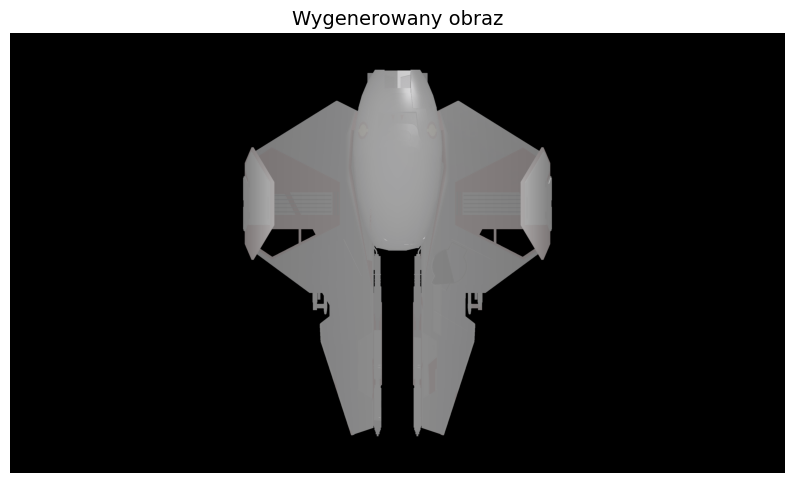

In [ ]:
# 1. Przeskalowanie wartości z przedziału [0.0, 1.0] do [0, 255]
# Jeśli Twoje dane z OpenGL są w innym formacie i mają już wartości 0-255, pomin to mnożenie.
image_data_uint8 = (buffer_data * 255).astype(np.uint8)

# 2. Utworzenie obiektu obrazu na podstawie tablicy NumPy
# Mode 'RGBA' oznacza, że mamy 4 kanały: Red, Green, Blue, Alpha
image = Image.fromarray(image_data_uint8, mode='RGBA')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Wygenerowany obraz", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
pip install moderngl-window pyrr Pillow numpy

In [ ]:
import numpy as np
import trimesh

# =====================================================================
# KROK 7: ZAPIS CHMURY PUNKTÓW DO PLIKU PLY (Architektura GPU)
# =====================================================================

# 1. Identyfikacja poprawnych fragmentów.
# Szukamy pikseli, gdzie Z jest mniejsze niż 1.0 (tło).
# Używamy tolerancji < 0.9999 z powodu specyfiki zapisu zmiennoprzecinkowego
# w pamięci VRAM (Depth24/Depth32F), aby uniknąć błędów zaokrągleń (floating point inaccuracies).
valid_y, valid_x = np.where(z_buffer < 0.9999)

# 2. Ekstrakcja głębokości z bufora
valid_z_normalized = z_buffer[valid_y, valid_x]

# 2.1. Ekstrakcja amplitudy dla usuniętych punktów
valid_color = color_buffer[valid_y, valid_x]

# =====================================================================
# UWAGA INŻYNIERYJNA: REKONSTRUKCJA GŁĘBOKOŚCI
# Zmienna `valid_z_normalized` przechowuje wartości od 0.0 do 1.0.
# Jeśli wstawisz je bezpośrednio obok `valid_x` (np. 500 px) i `valid_y`,
# Twoja chmura punktów będzie drastycznie "spłaszczona" na osi Z.
#
# Aby przywrócić pierwotne proporcje (World Space), musimy odwrócić
# sprzętowe rzutowanie, korzystając z parametrów `near` i `far`,
# których użyliśmy w macierzy `ortho_matrix` (od -1000.0 do +1000.0).
# =====================================================================
# Mapowanie liniowe z [0, 1] powrót do skali obiektu

# 1. Dekompresja sprzętowa: powrót z [0, 1] do rzeczywistych jednostek świata
valid_z_world_absolute = (valid_z_normalized * (far_plane - near_plane)) + near_plane

# 2. Przejście do przestrzeni "pikseli" (aby zrównać proporcje z osiami X i Y)
# Używamy tej samej skali (scale), którą obliczyliśmy na początku dla ekranu.
valid_z_pixel_space = (valid_z_world_absolute - z_center) * scale

# 3. Budowa macierzy punktów o jednorodnych jednostkach (wszystko w skali ekranu)
point_cloud_array = np.column_stack((valid_x, valid_y, valid_z_pixel_space))

#=========NOWOSC=========

# KONWERSJA AMPLITUDY DO SKALI SZAROŚCI W FORMACIE PLY (RGB/RGBA)
# Zmieniamy wartość 0.0-1.0 na 0-255 uint8 dla formatu koloru wierzchołków (Vertex Colors).
# Zdecydowana większość programów (np. CloudCompare) tak odczytuje intensywność.
amplitudes_8bit = (np.clip(valid_color, 0.0, 1.0) * 255).astype(np.uint8)

print(f"\nWygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: {len(point_cloud_array)}")

# 4. Inicjalizacja struktury i serializacja do pliku .ply
ply_filename = "/content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply"
pcd = trimesh.points.PointCloud(point_cloud_array, colors=valid_color)
pcd.export(ply_filename)

print(f"Pomyślnie zapisano sprzętową chmurę punktów do pliku: {ply_filename}")


Wygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: 1559084
Pomyślnie zapisano sprzętową chmurę punktów do pliku: /content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply
